# Preparation

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import gaussian, threshold_otsu
from skimage.segmentation import *
from skimage.color import rgb2gray, rgb2hsv
import skimage.io as skio
import re
from pathlib import Path
from typing import Literal
from skimage.feature import graycomatrix, graycoprops
import skimage.morphology as skmor
import skimage.measure as skmea
from skimage.morphology import (
    disk,
    binary_opening,
    binary_closing,
    remove_small_objects,
    remove_small_holes
)


Mounted at /content/gdrive


In [ ]:
# Used to unzip
#!unzip "/content/gdrive/MyDrive/BMET5933/AS1/assignment1_train_test_data.zip" -d "/content/gdrive/MyDrive/BMET5933/AS1"


In [ ]:
# ---function for reading csv file---
def read_label(csv_path: Path):

  df = pd.read_csv(csv_path)
  # Total dict
  label_dict = dict(zip(df['case_number'].astype(str), df['disease_status'].astype(str)))

  # benign and malignant dict
  benign_dict = { k: v for k, v in label_dict.items() if v == 'benign'}
  mali_dict = { k: v for k, v in label_dict.items() if v == 'malignant'}
  # Format: {'case_number': 'disease_status'}
  return label_dict, benign_dict, mali_dict


# func for converting case number into img path and mask path
def get_label_dict(label_dict: dict, dataset_root: Path):

  case_num_list = list(label_dict.keys())
  case_dict = {}

  # dict stores img_path, mask_path and status
  for num in case_num_list:
    case_dict[num] = {
        'img_path' : dataset_root / f'{num}.jpg',
        'mask_path' : dataset_root / f'{num}_Segmentation.png',
        'status': label_dict[num]
    }

  # Format: {'case_number': {'img_path': Path, 'mask_path': Path, 'status': str}}
  return case_dict

# func for getting sample list
def get_sample(case_dict: dict, length: int) -> list:
  '''
    return: list of case number
  '''
  return list(case_dict.keys())[0:length]


def get_path_from_dict(case_num: str, case_dict: dict)-> tuple[Path, Path]:
  '''
    get img and mask  path from case dict by calling case number
  '''
  img_path = case_dict[case_num]['img_path']
  mask_path = case_dict[case_num]['mask_path']

  return Path(img_path), Path(mask_path)


def get_img_from_path(img_path: Path) -> np.ndarray:
  '''
    Read image from path.

  '''
  img = skio.imread(img_path)
  return img


# func for get image(RGB/gray) by case
def get_img_from_case_num(case_num: str, case_dict: dict) -> tuple[np.ndarray, np.ndarray]:

  # read information from status dict
  img_path, mask_path = get_path_from_dict(case_num, case_dict)

  # read images from path
  img = get_img_from_path(img_path)
  mask = get_img_from_path(mask_path)

  return img, mask


def read_sample_list(sample_list, label_dict, lesion_mask = True):

	'''
		get img list for both RGB and gray images
		return: rgb_images, gray_images, mask_images
	'''
	rgb_images = []
	gray_images = []
	mask_images = []

	for case_num in sample_list:
		# get rgb img and mask by case number
		rgb_img, mask = get_img_from_case_num(case_num, label_dict)
		mask = np.asarray(mask) > 0
		# get gray img from rgb img
		gray_img = get_gray_image(rgb_img)

		# if lesion_mask is True, get lesion pixels for both rgb and gray img
		if lesion_mask:
			rgb_img = get_lesion_pixels(mask, rgb_img)
			gray_img = get_lesion_pixels(mask, gray_img)

		# append to list
		rgb_images.append(rgb_img)
		gray_images.append(gray_img)
		mask_images.append(mask)

	return rgb_images, gray_images, mask_images


# convert case_num list into gray/rgb img list, titles
def get_gray_image(img: np.ndarray):
	'''
		convert rgb img to gray img, if the input img is already gray, return the original img
	'''
	if img.ndim == 2:
		return img
	gray_img = rgb2gray(img)
	return gray_img


def get_lesion_pixels(mask: np.ndarray, img: np.ndarray) -> np.ndarray:
	'''
		get lesion pixels from the original image by applying the mask, if the input img is gray, return the original img
	'''
	mask = np.asarray(mask) > 0
	if img.ndim == 3:
		lesion_pixels = np.where(mask[:, :, None], img, 0)
	else:
		lesion_pixels = np.where(mask, img, 0)

	return lesion_pixels

def load_demo_data(demo_dataset: Path):
    # read demo dataset, return img list and mask list
	img_paths = sorted(demo_dataset.glob('*.jpg'))
	mask_paths = sorted(demo_dataset.glob('*.png'))
	full_imgs = []
	gray_imgs = []
	masks = []
    # read img and mask from path, get gray img, append to list
	for img_path, mask_path in zip(img_paths, mask_paths):
        # read img and mask from path
		img = get_img_from_path(img_path)
		mask = get_img_from_path(mask_path)
        # convert mask to binary mask, lesion pixels are True, background pixels are False
		mask = np.asarray(mask) < 0
		gray_img = get_gray_image(img)
		full_imgs.append(img)
		gray_imgs.append(gray_img)
		masks.append(mask)

  
	return full_imgs, gray_imgs, masks

def read_dataset(mode : Literal['train', 'test', 'demo'], lesion_mask = False):
	'''
		read dataset and return img list, gray img list and mask list
		lesion_mask: whether to use lesion mask or not, if False, use the whole image as mask
	'''
     
	# Path config
	TRAIN_DATASET = Path('/content/gdrive/MyDrive/BMET5933/AS1/assign_train/')
	TEST_DATASET = Path('/content/gdrive/MyDrive/BMET5933/AS1/assign_test/')
	TRAIN_CSV = Path('/content/gdrive/MyDrive/BMET5933/AS1/training_data_ground_truth.csv')
	TEST_CSV = Path('/content/gdrive/MyDrive/BMET5933/AS1/test_data_ground_truth.csv')
	DEMO_DATASET = Path('/content/gdrive/MyDrive/BMET5933/AS1/demo_data/')	

    # select csv path based on mode
	if mode == 'train':
		csv_path = TRAIN_CSV
	elif mode == 'test':
		csv_path = TEST_CSV
	elif mode == 'demo':
		return load_demo_data(DEMO_DATASET)
          
    # read csv file, format: {'case_number': 'disease_status'}    
	_, benign_dict, mali_dict = read_label(csv_path)
          
	# get case dict,format: {'case_number': {'img_path': Path, 'mask_path': Path, 'status': str}}
	mali_dict = get_label_dict(mali_dict, TRAIN_DATASET if mode == 'train' else TEST_DATASET)
	benign_dict = get_label_dict(benign_dict, TRAIN_DATASET if mode == 'train' else TEST_DATASET)

	# get list of case number
	mali_sample_list = get_sample(mali_dict, len(mali_dict.keys()))
	benign_sample_list = get_sample(benign_dict, len(benign_dict.keys()))

	# read img and mask
	mali_full_imgs, mali_gray_imgs, mali_masks = read_sample_list(mali_sample_list, mali_dict, lesion_mask)
	benign_full_imgs, benign_gray_imgs, benign_masks = read_sample_list(benign_sample_list, benign_dict, lesion_mask)
	
	return mali_full_imgs , benign_full_imgs, mali_gray_imgs , benign_gray_imgs, mali_masks , benign_masks

In [ ]:
# instantiation of training
training_set_dict, train_beng_dict, train_mali_dict = read_dataset(mode = 'train', lesion_mask = True)

# get benign and malignant dict storing img_path, mask_path and status(path_dict)
train_beng_dict = get_label_dict(train_beng_dict)
train_mali_dict = get_label_dict(train_mali_dict)

# sample from training set seperately
train_mali_sample = get_sample(train_mali_dict, len(train_mali_dict.keys()))
train_beng_sample = get_sample(train_beng_dict, len(train_beng_dict.keys()))

print(train_mali_sample)
print(train_beng_sample)

['ISIC_0000002', 'ISIC_0000004', 'ISIC_0000026', 'ISIC_0000029', 'ISIC_0000031', 'ISIC_0000035', 'ISIC_0000049', 'ISIC_0000078', 'ISIC_0000140', 'ISIC_0000143', 'ISIC_0000145', 'ISIC_0000146', 'ISIC_0000148', 'ISIC_0000150', 'ISIC_0000151', 'ISIC_0000153', 'ISIC_0000156', 'ISIC_0000171', 'ISIC_0000173', 'ISIC_0000277', 'ISIC_0000280', 'ISIC_0000285', 'ISIC_0000290', 'ISIC_0000292', 'ISIC_0000293', 'ISIC_0000297', 'ISIC_0000307', 'ISIC_0000412', 'ISIC_0000463', 'ISIC_0000469', 'ISIC_0000520', 'ISIC_0000521', 'ISIC_0000522', 'ISIC_0000552', 'ISIC_0001126', 'ISIC_0001134', 'ISIC_0001140', 'ISIC_0001148', 'ISIC_0009905', 'ISIC_0009934', 'ISIC_0009950', 'ISIC_0009971', 'ISIC_0010029', 'ISIC_0010036', 'ISIC_0010054', 'ISIC_0010194', 'ISIC_0010225', 'ISIC_0010235', 'ISIC_0010241', 'ISIC_0010265', 'ISIC_0010266', 'ISIC_0010321', 'ISIC_0010350', 'ISIC_0010358', 'ISIC_0010364', 'ISIC_0010372', 'ISIC_0010380', 'ISIC_0010441', 'ISIC_0010466', 'ISIC_0010468', 'ISIC_0010495', 'ISIC_0010576', 'ISIC_0

# Task1: Histograms

## Basic utility funcs:
	get path dict, img and gray img and lesion pixels

## Histogram calculation utility funcs

In [7]:
# get hist from img range
def get_hist(img, bin_number, mask = None)-> tuple[np.ndarray, np.ndarray]:
	img = np.asarray(img)
	mask_arr = None
	if mask is not None:
		mask_arr = np.asarray(mask) > 0

	# gray image
	if img.ndim == 2:
		pixels = img[mask_arr] if mask_arr is not None else img.ravel()
		hist, bin_edges = np.histogram(pixels, bins = bin_number, range = (0, 1))
		return hist, bin_edges

	# rgb image
	else:
		channel_hists = []
		for i in range(3):
			channel = img[:, :, i]
			pixels = channel[mask_arr] if mask_arr is not None else channel.ravel()
			hist, bin_edges = np.histogram(pixels, bins = bin_number, range = (0, 255))
			channel_hists.append(hist)
		return np.array(channel_hists), bin_edges


def get_avg_hist(hists: np.ndarray):
	'''
		calculate avg hist
		return: avg_hist
	'''
	avg_hist = np.mean(hists, axis = 0)
	return avg_hist


## Histogram plot utility funcs

In [8]:
def hist_plot(hist: np.ndarray, bin_edges: np.ndarray, title: str, y_limit = None):

	# plot gray image histogram
	if hist.ndim == 1:
		plt.figure()
		plt.title(title)
		widths = np.diff(bin_edges)
		plt.bar(bin_edges[:-1], hist, width = widths, align = 'edge')
		plt.yscale('log')
		if y_limit is not None:
			plt.ylim(y_limit)
		plt.show()

	# plot rgb image histogram
	elif hist.ndim == 2 and hist.shape[0] == 3:
		channel_names = ['red', 'green', 'blue']
		fig, ax = plt.subplots(3,1, figsize = (8, 10) ,sharex = True)
		for i in range(3):
			widths = np.diff(bin_edges)
			ax[i].bar(bin_edges[:-1], hist[i], width = widths, align = 'edge', color = channel_names[i])
			ax[i].set_title(f'{title} - {channel_names[i]}')
			ax[i].set_yscale('log')
			if y_limit is not None:
				ax[i].set_ylim(y_limit)
		plt.show()
	return

##  RGB/gray img list and histogram list utility funcs

In [ ]:




def get_hist_list(img_list, bin_number, mask_list = None):
	# histogram list
	hist_list = []
	bin_edges = None

	for idx, img in enumerate(img_list):
		# get mask if mask_list is provided
		mask = None if mask_list is None else mask_list[idx]
		hist, bin_edges = get_hist(img, bin_number = bin_number, mask = mask)
		hist_list.append(hist)

	return hist_list, bin_edges


## 1.1. Get img list, histogram list and avg hist

In [10]:
bin_number = 150
# Benign data processing
# --- full benign imgs ---
# full img list and mask list for benign data
rgb_train_beng_full_imgs, gray_train_beng_full_imgs, train_beng_masks = read_sample_list(
	train_beng_sample,
	train_beng_dict,
	lesion_mask = False
)



# --- histogram processing for benign data ---
# get rgb hist list on benign data using lesion pixels only
rgb_train_beng_hists, rgb_train_beng_bin_edges = get_hist_list(
	rgb_train_beng_full_imgs,
	bin_number = bin_number,
	mask_list = train_beng_masks
)

# gray hist list on benign data using lesion pixels only
gray_train_beng_hists, gray_train_beng_bin_edges = get_hist_list(
	gray_train_beng_full_imgs,
	bin_number,
	mask_list = train_beng_masks
)

# gray and rgb avg histogram
avg_gray_train_beng_hist = get_avg_hist(gray_train_beng_hists)
avg_rgb_train_beng_hist = get_avg_hist(rgb_train_beng_hists)

In [11]:
# malignant imgs and histograms processing
# --- full malignant imgs ---
rgb_train_mali_full_imgs, gray_train_mali_full_imgs, train_mali_masks = read_sample_list(
	train_mali_sample,
	train_mali_dict,
	lesion_mask = False
)

# --- histogram processing for malignant data ---
# rgb hist list on malignant data using lesion pixels only
rgb_train_mali_hists, rgb_train_mali_bin_edges = get_hist_list(
	rgb_train_mali_full_imgs,
	bin_number,
	mask_list = train_mali_masks
)
# gray hist list on malignant data using lesion pixels only
gray_train_mali_hists, gray_train_mali_bin_edges = get_hist_list(
	gray_train_mali_full_imgs,
	bin_number,
	mask_list = train_mali_masks
)

# gray and rgb avg histogram
avg_gray_train_mali_hist = get_avg_hist(gray_train_mali_hists)
avg_rgb_train_mali_hist = get_avg_hist(rgb_train_mali_hists)

## 1.2. Malignant and benign avg gray histogram

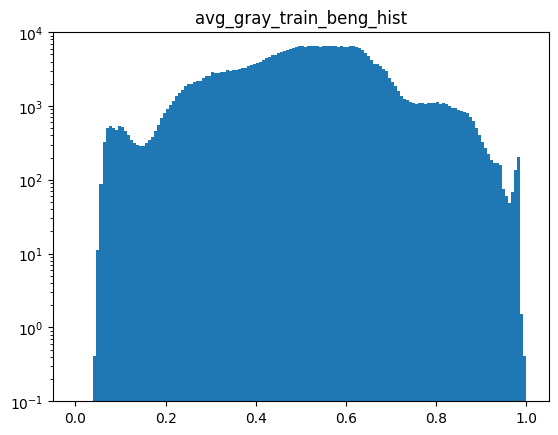

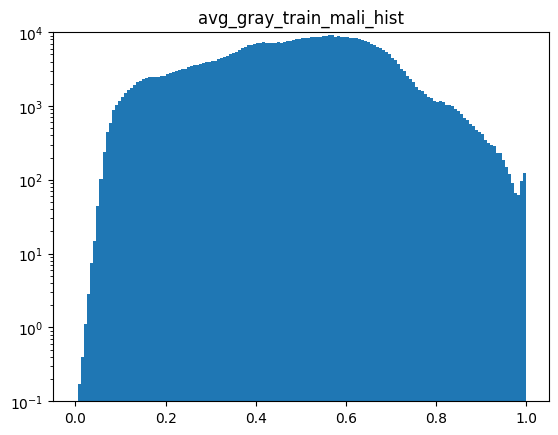

In [12]:
# --- plot gray scale histograms ---
# set y limit for better visualization
gray_avg_y_limit = (1e-1, max(np.max(avg_gray_train_beng_hist), np.max(avg_gray_train_mali_hist)) * 1.1)

# plot gray avg histograms for both benign and malignant data
hist_plot(avg_gray_train_beng_hist, gray_train_beng_bin_edges, title = 'avg_gray_train_beng_hist', y_limit = gray_avg_y_limit)
hist_plot(avg_gray_train_mali_hist, gray_train_mali_bin_edges, title = 'avg_gray_train_mali_hist', y_limit = gray_avg_y_limit)

## 1.3. Malignant and benign rgb average histogram

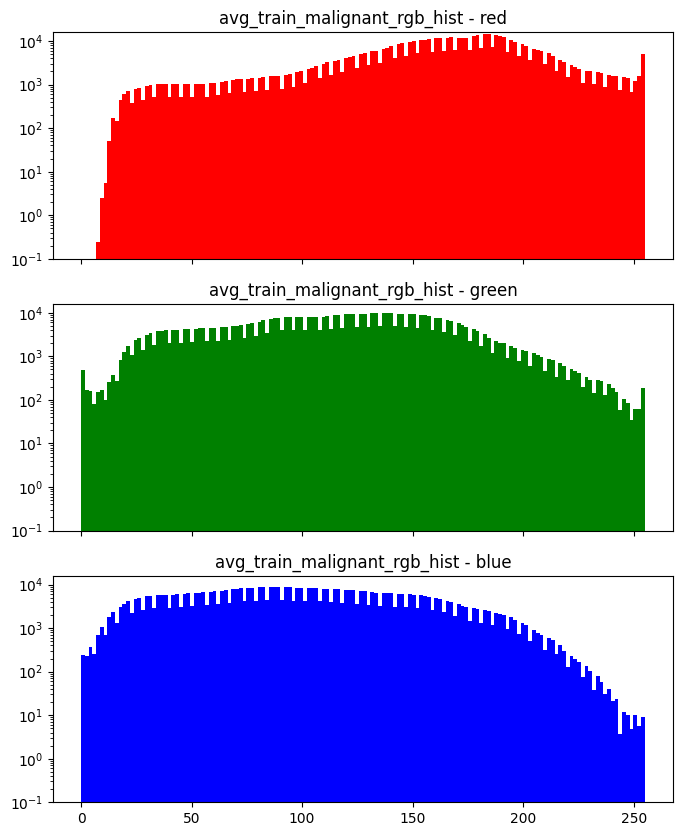

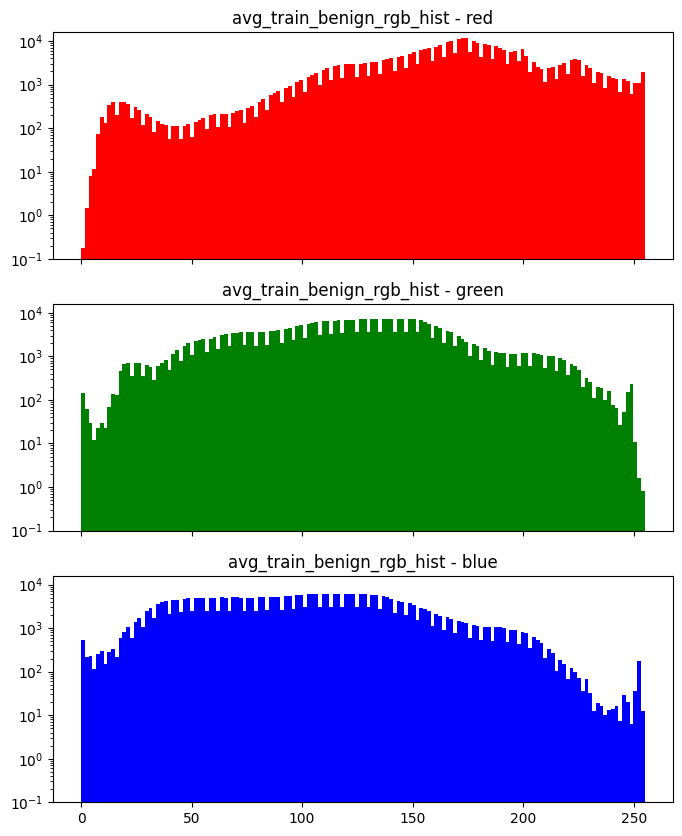

In [13]:
# --- plot rgb average histograms ---
# set y limit for better visualization
rgb_avg_y_limit = (1e-1, max(np.max(avg_rgb_train_mali_hist), np.max(avg_rgb_train_beng_hist)) * 1.1)

# malignant rgb average histogram
hist_plot(avg_rgb_train_mali_hist, rgb_train_mali_bin_edges, title = 'avg_train_malignant_rgb_hist', y_limit = rgb_avg_y_limit)

# benign rgb average histogram
hist_plot(avg_rgb_train_beng_hist, rgb_train_beng_bin_edges, title = 'avg_train_benign_rgb_hist', y_limit = rgb_avg_y_limit)

# Task2: Feature extraction

## GLCM properities calculation untility funcs

In [14]:
def crop_to_mask_bbox(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    '''
    Crop an image to the lesion mask bounding box.
    return: cropped image
    '''
    mask = np.asarray(mask) > 0
    rows, cols = np.where(mask)
    return img[rows.min():rows.max() + 1, cols.min():cols.max() + 1]


def get_binned_img(img_list, levels: int = 8):
    '''
    Quantize a list of gray images into [0, levels - 1].

    Input:
        img_list: list of np.ndarray, each image shape is (H, W)
        levels: int, number of gray levels for GLCM

    Output:
        binned_img_list: list of np.ndarray, each image shape is (H, W), dtype uint8
    '''
    binned_img_list = []

    for img in img_list:
        img = np.asarray(img, dtype = np.float64)
        img = np.clip(img, 0, 1)
        binned_img = np.floor(img * (levels - 1)).astype(np.uint8)
        binned_img_list.append(binned_img)

    return binned_img_list


def get_avg_glcm_props(glcmatrix_list, prop_name: Literal['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']):
	'''
		calculate avg glcmatrix coprops
	'''
	glcm_props = []
	for glcmatrix in glcmatrix_list:
		glcm_prop = graycoprops(glcmatrix, prop_name)[0, 0]
		glcm_props.append(glcm_prop)

	avg_glcm_prop = float(np.mean(glcm_props))

	return avg_glcm_prop


## rgb/hsv color feature calculation ultility funcs

In [15]:
def _get_valid_rgb_pixels(img: np.ndarray, mask = None) -> np.ndarray:
	if mask is None:
		return img.reshape(-1, 3)

	mask = np.asarray(mask) > 0
	return img[mask]


def get_rgb_means(img_list, mask_list = None):
	'''
		calculate rgb means
	'''
	rgb_means = []

	for idx, img in enumerate(img_list):
		mask = None if mask_list is None else mask_list[idx]
		pixels = _get_valid_rgb_pixels(img, mask)
		rgb_means.append(np.mean(pixels, axis = 0))

	rgb_means = np.array(rgb_means)
	rgb_means = np.mean(rgb_means, axis = 0)
	return rgb_means


def get_rgb_std(img_list, mask_list = None):
	'''
		calculate rgb std
	'''
	rgb_stds = []
	for idx, img in enumerate(img_list):
		mask = None if mask_list is None else mask_list[idx]
		pixels = _get_valid_rgb_pixels(img, mask)
		rgb_stds.append(np.std(pixels, axis = 0))

	rgb_stds = np.array(rgb_stds)
	rgb_stds = np.mean(rgb_stds, axis = 0)
	return rgb_stds


def get_hsv_means(img_list, mask_list = None):
	'''
		calculate hsv means
	'''
	hsv_means = []
	for idx, img in enumerate(img_list):
		mask = None if mask_list is None else mask_list[idx]
		hsv_img = rgb2hsv(img)
		pixels = _get_valid_rgb_pixels(hsv_img, mask)
		hsv_means.append(np.mean(pixels, axis = 0))

	hsv_means = np.array(hsv_means)
	hsv_means = np.mean(hsv_means, axis = 0)
	return hsv_means


def get_hsv_std(img_list, mask_list = None):
	'''
		calculate hsv std
	'''
	hsv_stds = []
	for idx, img in enumerate(img_list):
		mask = None if mask_list is None else mask_list[idx]
		hsv_img = rgb2hsv(img)
		pixels = _get_valid_rgb_pixels(hsv_img, mask)
		hsv_stds.append(np.std(pixels, axis = 0))

	hsv_stds = np.array(hsv_stds)
	hsv_stds = np.mean(hsv_stds, axis = 0)
	return hsv_stds


## 2.1 Bin imgs

In [16]:
GLCM_LEVELS = 8

gray_train_beng_roi_imgs = [crop_to_mask_bbox(img, mask) for img, mask in zip(gray_train_beng_full_imgs, train_beng_masks)]
gray_train_mali_roi_imgs = [crop_to_mask_bbox(img, mask) for img, mask in zip(gray_train_mali_full_imgs, train_mali_masks)]

# binned gray imgs for GLCM
binned_gray_train_beng_imgs = get_binned_img(gray_train_beng_roi_imgs, GLCM_LEVELS)
binned_gray_train_mali_imgs = get_binned_img(gray_train_mali_roi_imgs, GLCM_LEVELS)


## 2.2. GLCM feature

In [17]:
glcmatrix_train_beng_imgs = []
glcmatrix_train_mali_imgs = []

# gray co occcurance matrix calculation
for img in binned_gray_train_beng_imgs:
    glcmatrix = graycomatrix(
          					img, 
                            distances=[1], 
                            angles=[0], 
                            levels= GLCM_LEVELS, 
                            symmetric=False, 
                            normed=True
                            )
    glcmatrix_train_beng_imgs.append(glcmatrix)
    
for img in binned_gray_train_mali_imgs:
	glcmatrix = graycomatrix(
            				img, 
                          	distances=[1], 
                            angles=[0], 
                            levels=GLCM_LEVELS, 
                            symmetric=False, 
                            normed=True
                            )
	glcmatrix_train_mali_imgs.append(glcmatrix)

In [18]:
prop_name_list = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
# calculate avg glcm props for benign and malignant data
avg_glcm_props_train_beng = {}
avg_glcm_props_train_mali = {}

for prop_name in prop_name_list:
	avg_glcm_props_train_beng[prop_name] = get_avg_glcm_props(glcmatrix_train_beng_imgs, prop_name)
	avg_glcm_props_train_mali[prop_name] = get_avg_glcm_props(glcmatrix_train_mali_imgs, prop_name)

glcm_features = {
	'benign': avg_glcm_props_train_beng,
	'malignant': avg_glcm_props_train_mali
}

glcm_features

{'benign': {'contrast': 0.05705664857264698,
  'dissimilarity': 0.05631548942166367,
  'homogeneity': 0.9719151579987105,
  'energy': 0.5656422526730625,
  'correlation': 0.961085081075326,
  'ASM': 0.3334169343486372},
 'malignant': {'contrast': 0.061795500907533725,
  'dissimilarity': 0.06071908467233854,
  'homogeneity': 0.9697433286996312,
  'energy': 0.5358204550148776,
  'correlation': 0.963596083744373,
  'ASM': 0.29626221540493636}}

## 2.3. rgb/hsv color feature

In [19]:
def get_rgb_hsv_color_features(img_list, mask_list):
	return {
			'rgb_means': get_rgb_means(img_list, mask_list),
			'rgb_stds': get_rgb_std(img_list, mask_list),
			'hsv_means': get_hsv_means(img_list, mask_list),
			'hsv_stds': get_hsv_std(img_list, mask_list)
}


In [20]:
# calculate rgb and hsv color features for benign and malignant data
rgb_hsv_color_features = {
	'benign': get_rgb_hsv_color_features(rgb_train_beng_full_imgs, train_beng_masks),
	'malignant': get_rgb_hsv_color_features(rgb_train_mali_full_imgs, train_mali_masks)
}

rgb_hsv_color_features

{'benign': {'rgb_means': array([169.45912747, 121.97795011,  97.56042119]),
  'rgb_stds': array([22.05168363, 29.98968806, 32.17551709]),
  'hsv_means': array([0.11130041, 0.44055432, 0.66501712]),
  'hsv_stds': array([0.08821562, 0.13001964, 0.08676309])},
 'malignant': {'rgb_means': array([162.22565672, 116.90302828,  99.27407545]),
  'rgb_stds': array([24.32257098, 30.73953422, 32.76205007]),
  'hsv_means': array([0.17259618, 0.4169598 , 0.63854243]),
  'hsv_stds': array([0.14434202, 0.13128252, 0.09628328])}}

## 2.4. Shape features:

In [21]:
def get_mask_area(mask):
	'''
		calculate mask area by counting non zero pixels in the mask
	'''
	mask_area = int(np.sum(mask > 0))
	return mask_area


def get_mask_perimeter(mask):
	'''
		calculate mask perimeter by counting non zero pixels in the mask boundary
	'''
	perimeter = float(skmea.perimeter(mask > 0))
	return perimeter


def get_mask_circularity(mask):
	'''
		calculate mask circularity by using the formula: circularity = 4 * pi * area / (perimeter^2)
	'''
	area = get_mask_area(mask)
	perimeter = get_mask_perimeter(mask)
	if perimeter == 0:
		return 0.0
	circularity = 4 * np.pi * area / (perimeter ** 2)
	return float(circularity)


def get_mask_solidity(mask):
	'''
		calculate mask solidity by using the formula: solidity = area / convex_area
	'''
	mask = mask > 0
	labeled_mask = skmea.label(mask)
	region = skmea.regionprops(labeled_mask)
	largest_region = max(region, key = lambda x: x.area)
	solidity = largest_region.solidity
	return float(solidity)


In [22]:
def get_avg_shape_features(mask_list):
	return {
		'area': float(np.mean([get_mask_area(mask) for mask in mask_list])),
		'perimeter': float(np.mean([get_mask_perimeter(mask) for mask in mask_list])),
		'circularity': float(np.mean([get_mask_circularity(mask) for mask in mask_list])),
		'solidity': float(np.mean([get_mask_solidity(mask) for mask in mask_list]))
	}


In [23]:

# shape features for benign and malignant data
shape_features = {
	'benign': get_avg_shape_features(train_beng_masks),
	'malignant': get_avg_shape_features(train_mali_masks)
}

shape_features

{'benign': {'area': 363810.6666666667,
  'perimeter': 2438.540376608653,
  'circularity': 0.6893922536903041,
  'solidity': 0.9554991390177355},
 'malignant': {'area': 568262.4,
  'perimeter': 2982.0412040939077,
  'circularity': 0.6597698644716525,
  'solidity': 0.9414865542507493}}

# Task3: Segmentation

In [45]:

# Test label dict
test_set_dict, test_beng_dict_raw, test_mali_dict_raw = read_label(TEST_CSV)

# benign / malignant split for test
test_beng_dict = get_label_dict(test_beng_dict_raw, TEST_DATASET)
test_mali_dict = get_label_dict(test_mali_dict_raw, TEST_DATASET)

# Sample list
test_beng_sample = get_sample(test_beng_dict, len(test_beng_dict.keys()))
test_mali_sample = get_sample(test_mali_dict, len(test_mali_dict.keys()))

test_beng_full_imgs, test_beng_gray_imgs, test_beng_masks = read_sample_list(test_beng_sample, test_beng_dict, lesion_mask = False)
test_mali_full_imgs, test_mali_gray_imgs, test_mali_masks = read_sample_list(test_mali_sample, test_mali_dict, lesion_mask = False)


In [50]:
def gaussian_smooth(img, sigma = 1):
	'''
		apply gaussian smoothing to the image
		return: smoothed image
	'''
	smoothed_img = gaussian(img, sigma = sigma)
	return smoothed_img

def get_otsu_threshold(img):
	'''
		calculate otsu threshold for the image
		return: otsu threshold
	'''
	threshold = threshold_otsu(img)
	return threshold

def get_binary_mask(img, threshold, status:Literal['dark', 'light'] = 'light'):
	'''
		get binary mask by applying threshold to the image
		return: binary mask
	'''
	if status == 'dark':
		binary_mask = img > threshold
	else:
		binary_mask = img < threshold
	return np.array(binary_mask, dtype=np.uint8)

def keep_largest_connected_component(mask):
	'''
		keep the largest connected component in the binary mask
		return: binary mask with only the largest connected component
	'''
	labeled_mask = skmea.label(mask)
	regions = skmea.regionprops(labeled_mask)
	largest_region = max(regions, key = lambda x: x.area)
	largest_region_mask = labeled_mask == largest_region.label
	return largest_region_mask.astype(np.uint8)

def get_segmentation_lesion(img, sigma = 1, closing_disk_radius = 5, opening_disk_radius = 5, min_size = 200, min_hole_size = 200):
	'''
		get segmentation mask by applying gaussian smoothing, otsu thresholding and keeping the largest connected component
		return: binary mask with only the largest connected component
	'''
	# convert to gray image if the input image is RGB
	if img.ndim ==3:
		gray_img = rgb2gray(img)
	elif img.ndim == 2:
		gray_img = img
	#gaussian smoothing
	smoothed_img = gaussian_smooth(gray_img, sigma)
	# calculate otsu threshold
	otsu_threshold = get_otsu_threshold(smoothed_img)
	# get binary mask by applying otsu threshold
	binary_mask = get_binary_mask(smoothed_img, otsu_threshold, status='light')
	# keep the largest connected component in the binary mask
	largest_region_mask = keep_largest_connected_component(binary_mask)

	# --- morphological operations to refine the mask ---
	# define structuring element 
	struturing_element = disk(closing_disk_radius)
	# closing to fill small holes
	closed_mask = binary_closing(largest_region_mask, struturing_element)
	
	# opening to remove small objects
	struturing_element = disk(opening_disk_radius)
	opened_mask = binary_opening(closed_mask, struturing_element)

	# remove small objects
	final_mask = remove_small_objects(opened_mask, min_size = min_size)
	# remove small holes
	final_mask = remove_small_holes(final_mask, area_threshold = min_hole_size)

	return final_mask.astype(np.uint8)


In [51]:
# define evaluation metrics

def get_segmentation_metrics(pred_mask: np.ndarray, gt_mask: np.ndarray) -> dict:
    """
    Compute segmentation metrics.

    Input:
        pred_mask: np.ndarray, shape (H, W), dtype bool
        gt_mask: np.ndarray, shape (H, W), dtype bool

    Output:
        metrics: dict
    """
    pred_mask = np.asarray(pred_mask).astype(bool)
    gt_mask = np.asarray(gt_mask).astype(bool)

    tp = np.logical_and(pred_mask, gt_mask).sum()
    tn = np.logical_and(~pred_mask, ~gt_mask).sum()
    fp = np.logical_and(pred_mask, ~gt_mask).sum()
    fn = np.logical_and(~pred_mask, gt_mask).sum()

    dice = (2 * tp) / (2 * tp + fp + fn + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)

    return {
        'dice': float(dice),
        'iou': float(iou),
        'sensitivity': float(sensitivity),
        'specificity': float(specificity),
        'tp': int(tp),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn)
    }

def show_segmentation_result(rgb_img, gt_mask, pred_mask: np.ndarray):
    """
    Visualize original image, ground-truth mask and predicted mask.

    Input:
        rgb_img: np.ndarray, shape (H, W, 3) or (H, W)
        gt_mask: np.ndarray, shape (H, W), dtype bool
        pred_mask: np.ndarray, shape (H, W), dtype bool
    """

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].imshow(rgb_img)
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    ax[1].imshow(gt_mask, cmap='gray')
    ax[1].set_title('Ground Truth Mask')
    ax[1].axis('off')

    ax[2].imshow(pred_mask, cmap='gray')
    ax[2].set_title('Predicted Mask')
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()

In [52]:
def evaluate(img, gt_mask, sigma = 1, closing_disk_radius = 5, opening_disk_radius = 5, min_size = 200, min_hole_size = 200):
	"""
	Evaluate segmentation performance by computing metrics and visualizing results.

	Input:
		img: np.ndarray, shape (H, W, 3) or (H, W)
		gt_mask: np.ndarray, shape (H, W), dtype bool
		sigma: float, optional, default=1, Gaussian smoothing sigma
	"""
	# get predicted mask
	pred_mask = get_segmentation_lesion(img, sigma, closing_disk_radius = closing_disk_radius, opening_disk_radius = opening_disk_radius, min_size = min_size, min_hole_size = min_hole_size)
	# compute metrics
	metrics = get_segmentation_metrics(pred_mask, gt_mask)
	# visualize results
	show_segmentation_result(img, gt_mask, pred_mask)

	return metrics

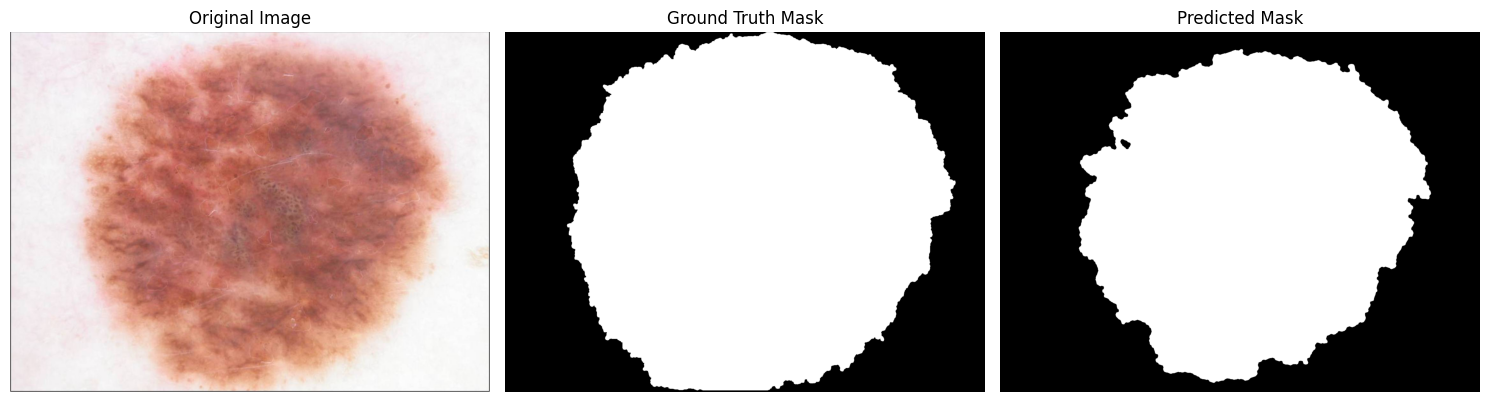

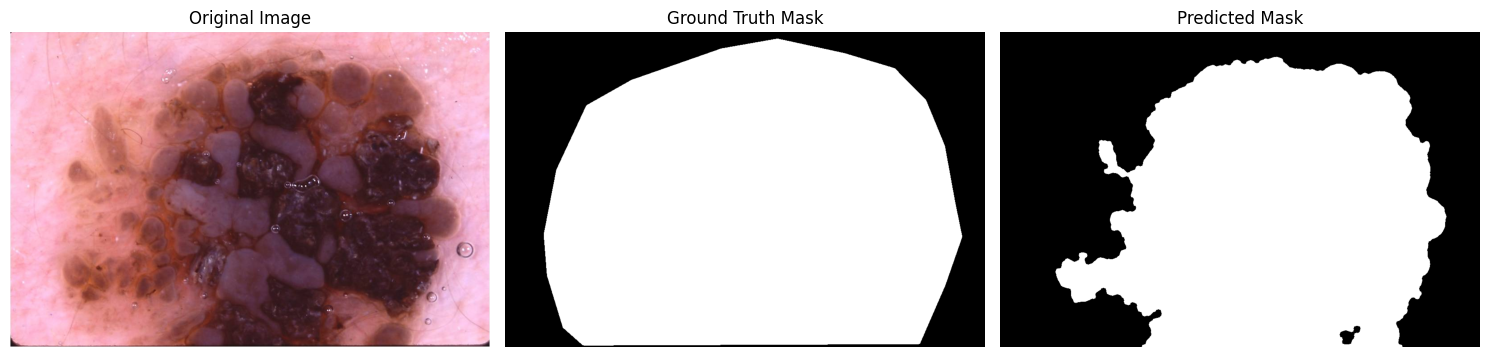

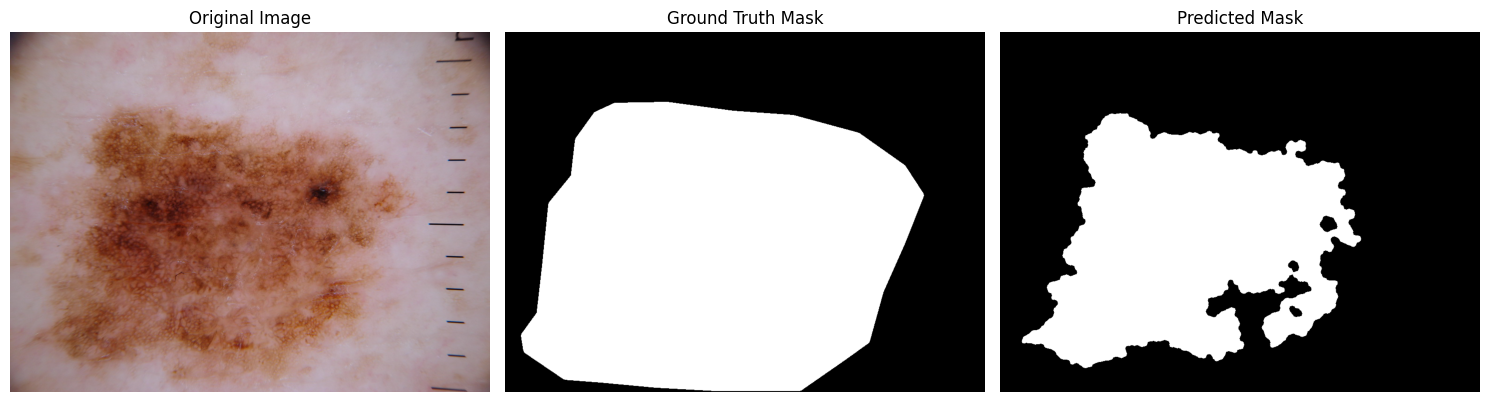

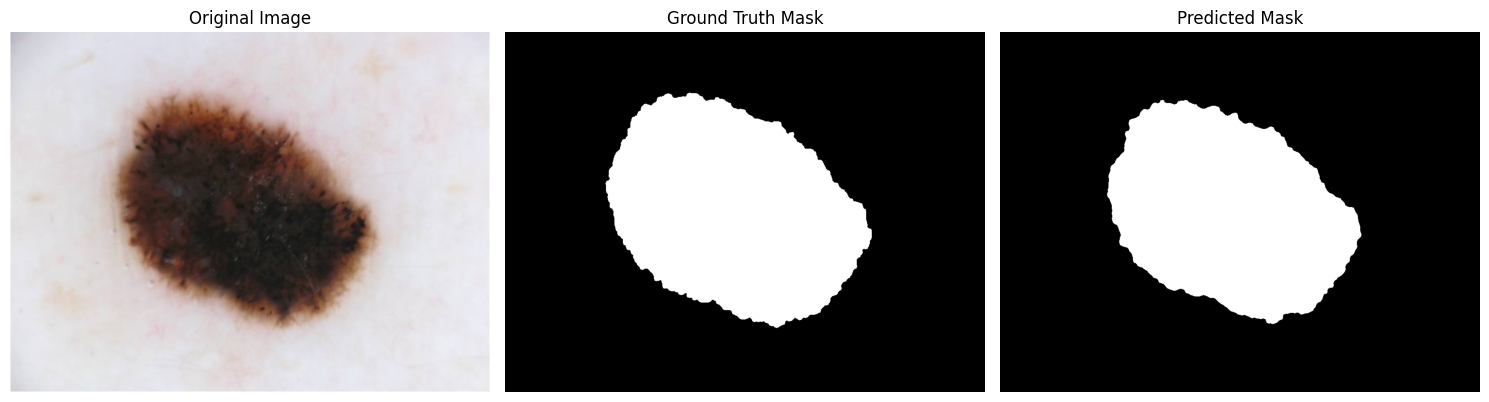

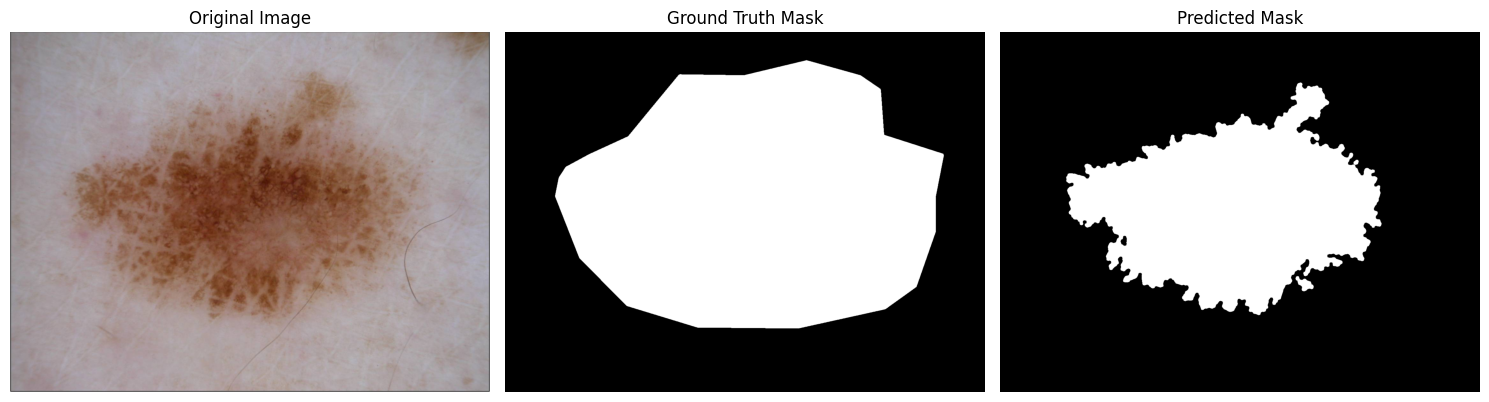

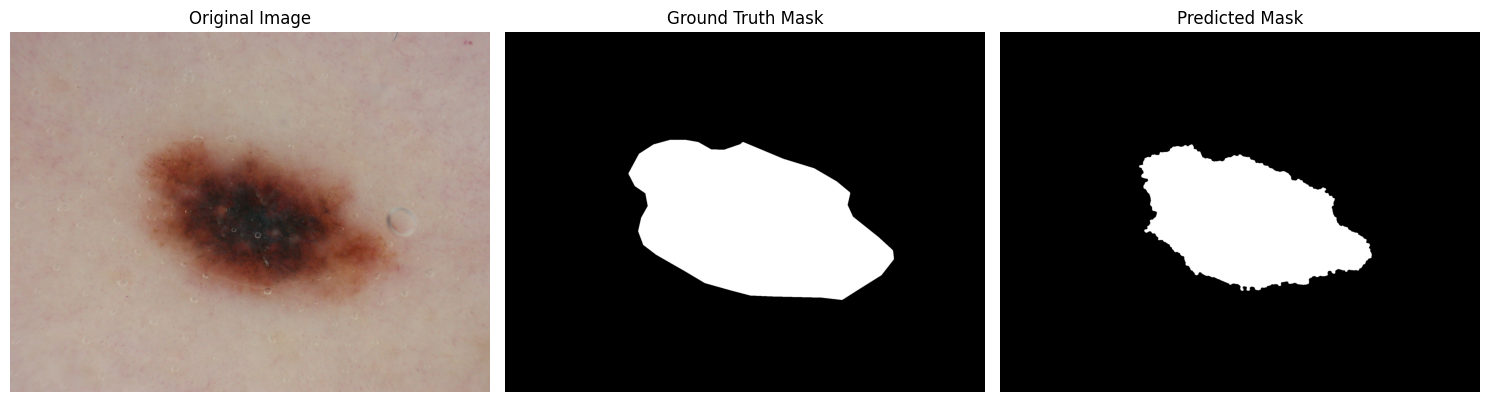

In [53]:

# evaluate segmentation performance on benign and malignant data
benign_metrics_list = []
for img, gt_mask in list(zip(test_beng_full_imgs, test_beng_masks))[:3]:
	metrics = evaluate(img, gt_mask, sigma = 1.5, closing_disk_radius = 5, opening_disk_radius = 5, min_size = 200, min_hole_size = 200)
	benign_metrics_list.append(metrics)

# evaluate malignant data
malignant_metrics_list = []
for img, gt_mask in list(zip(test_mali_full_imgs, test_mali_masks))[:3]:
	metrics = evaluate(img, gt_mask, sigma = 1.5, closing_disk_radius = 5, opening_disk_radius = 5, min_size = 200, min_hole_size = 200)
	malignant_metrics_list.append(metrics)